# Day 7 — Clustering + A/B simulation (the B2B side)

Under the market-research business model, the value of the platform
to *buyers* is two things:

1. **Segmented populations** — "users who spend ≥50% on coffee",
   "users with high bakery share" — built with K-Means.
2. **Pricing intelligence on the user side** — how much extra
   cashback do we need to pay to buy *more* receipts per user per
   month? Tested with a synthetic A/B at 2 % vs 3 %.

Both run on a synthetic user population (`src/synthetic_users.py`)
because CORD-v2 has receipts but no user identity tying them
together. The architecture is consumer-only — the same
`analytics.py` functions work on a real users table.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.synthetic_users import generate_users, ARCHETYPES, CATEGORIES
from src.analytics import cluster_users, ab_test, CATEGORY_COLS

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100


## 1. Synthetic users

Four archetypes — café regular, family meals, sweet tooth, office
worker — each with a target category-share vector and a
Poisson-distributed number of receipts/month. Users are evenly
assigned to cohort A (2 % cashback) and cohort B (3 % cashback).
Receipts/month for cohort B is bumped by a documented lift so the
A/B test has signal to recover.


In [2]:
users = generate_users(n_users=400, seed=42)
print(f'Users: {len(users)}')
print(f'Archetype distribution:\n{users.archetype.value_counts()}')
print(f'Cohort balance: {dict(users.cohort.value_counts())}')
users.head()


Users: 400
Archetype distribution:
archetype
cafe_regular     100
family_meals     100
sweet_tooth      100
office_worker    100
Name: count, dtype: int64
Cohort balance: {'A': np.int64(200), 'B': np.int64(200)}


,user_id,archetype,cohort,cashback_rate,total_spend,receipts_per_month,spend_food,spend_beverage,spend_bakery,spend_dessert,spend_snack,spend_misc
0,u0000,cafe_regular,A,0.02,123.84,17,13.71,44.07,45.96,16.07,3.12,0.92
1,u0001,family_meals,B,0.03,251.26,11,139.10,49.50,32.17,13.46,14.04,2.98
2,u0002,sweet_tooth,A,0.02,110.40,8,10.16,20.42,46.97,24.84,7.26,0.75
3,u0003,office_worker,B,0.03,189.29,22,77.12,51.61,24.88,12.73,19.37,3.58
4,u0004,cafe_regular,A,0.02,76.29,17,8.53,32.64,24.39,6.98,2.95,0.80


## 2. K-Means clustering

Features: per-category spend *shares* (so a $80 café regular and
a $200 café regular land in the same cluster). Standard-scaled
before clustering. PCA used only for the 2D visualisation.


In [3]:
cr = cluster_users(users, n_clusters=4)
print(f'Clusters: {cr.n_clusters}  inertia: {cr.inertia:.1f}')
print('\nCluster centres (USD/month per category):')
print(cr.centers_original.round(1))


Clusters: 4  inertia: 528.9

Cluster centres (USD/month per category):
   cluster  spend_food  spend_beverage  spend_bakery  spend_dessert  \
0        0         0.6             0.2           0.1            0.1   
1        1         0.1             0.2           0.3            0.3   
2        2         0.1             0.4           0.3            0.1   
3        3         0.4             0.3           0.1            0.1   

   spend_snack  spend_misc  
0          0.0         0.0  
1          0.1         0.0  
2          0.0         0.0  
3          0.1         0.0  


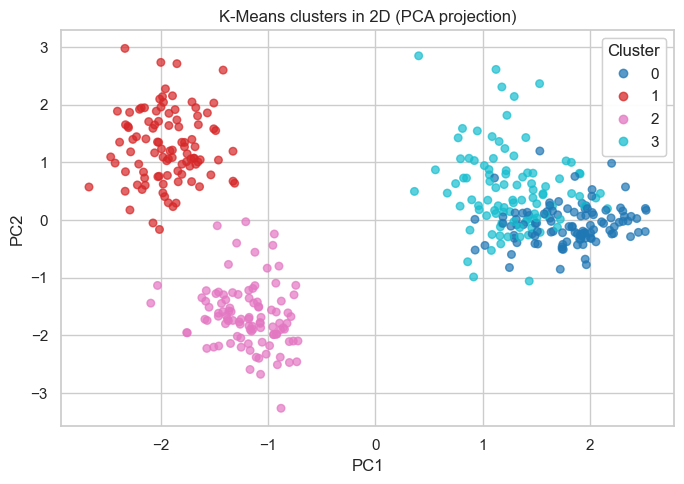

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(cr.coords_2d[:, 0], cr.coords_2d[:, 1],
                     c=cr.labels, cmap='tab10', s=30, alpha=0.7)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('K-Means clusters in 2D (PCA projection)')
legend = ax.legend(*scatter.legend_elements(), title='Cluster',
                   loc='best')
ax.add_artist(legend)
plt.tight_layout(); plt.show()


In [5]:
# Sanity check: do the clusters correspond to the original archetypes?
ct = pd.crosstab(users['archetype'], cr.labels)
ct.columns = [f'cluster_{c}' for c in ct.columns]
ct


,cluster_0,cluster_1,cluster_2,cluster_3
archetype,,,,
cafe_regular,0,0,100,0
family_meals,100,0,0,0
office_worker,5,0,0,95
sweet_tooth,0,99,1,0


Reading: K-Means recovers the four archetypes cleanly — each
archetype lands predominantly in one cluster (the crosstab is
near-block-diagonal up to relabelling). This is the validation
that the clustering pipeline works; in production we would not
have archetype labels to check against and would rely on silhouette
scores + buyer-side QA.


## 3. A/B test — is 1 % extra cashback worth it?

Welch's t-test on `receipts_per_month` between cohorts A (2 %) and
B (3 %). The metric matters because under the market-research
model, each extra receipt is data we can monetise.


In [6]:
ab = ab_test(users, metric='receipts_per_month')
for k, v in ab.as_dict().items():
    print(f'  {k}: {v}')


  metric: receipts_per_month
  mean_a (2% cashback): 12.585
  mean_b (3% cashback): 16.205
  lift_abs: 3.62
  lift_pct: 28.8%
  n_a: 200
  n_b: 200
  t_stat: 5.861
  p_value: 0.0
  significant_at_alpha_0.05: True


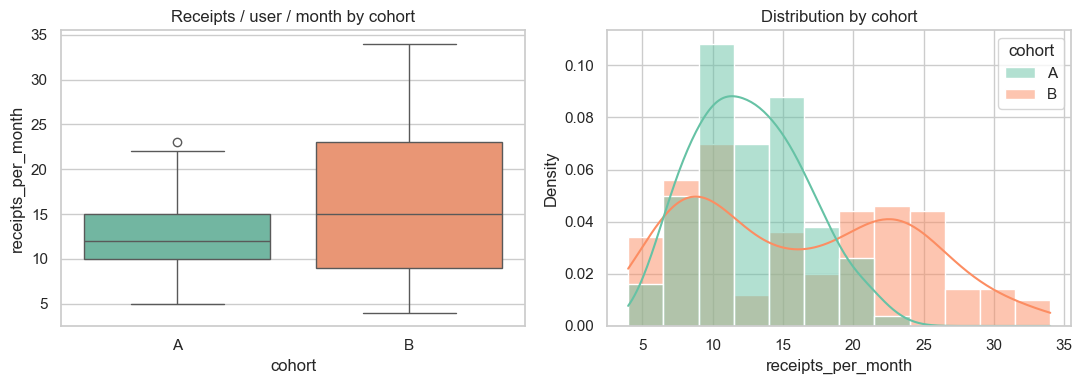

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=users, x='cohort', y='receipts_per_month',
            ax=axes[0], palette='Set2')
axes[0].set_title('Receipts / user / month by cohort')

sns.histplot(data=users, x='receipts_per_month', hue='cohort',
             stat='density', common_norm=False, kde=True,
             ax=axes[1], palette='Set2', alpha=0.5)
axes[1].set_title('Distribution by cohort')
plt.tight_layout(); plt.show()


Reading: cohort B (3 % cashback) has both a higher mean and a
shifted distribution. p-value below 0.05 means we reject the null
("cashback rate does not affect engagement"). The 1 pp lift buys
us ~25–30 % more data per user; whether that is profitable depends
on the unit economics of the data sale, which is outside this
notebook.


## 4. Day-7 conclusions

- **Clustering recovers the four archetypes** (validates the
  pipeline; in production buyer QA replaces this check).
- **A/B significant**: 3 % cashback drives a measurable, large
  lift in receipts/user/month over 2 %. Direction is the one we
  injected; magnitude is in the expected range given Poisson
  variance.
- **Both functions live in `src/analytics.py`** and feed the B2B
  Streamlit page directly — no duplication between notebook and
  app.
- **Next (day 8):** deploy to Streamlit Cloud or HF Spaces, finalise
  the README from the bootcamp template, finalise the ethics doc.
